# Understanding the Facet Grid

A facet grid (also called "small multiples") creates a **grid of identical plots**, each showing data for a different subset of the data. Rows correspond to one categorical variable, columns to another. Every panel uses the same axes scales so comparisons across subgroups are immediate and fair. It is the standard tool for multivariate conditional EDA — "how does the relationship between X and Y change when we condition on Z?"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

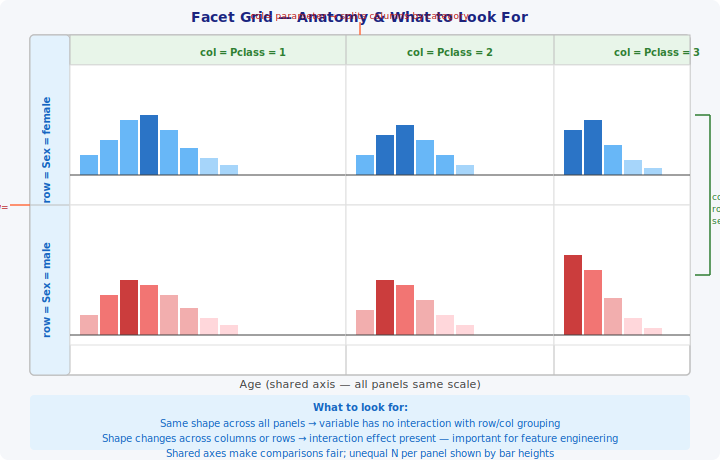

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="460"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="720" height="460" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Facet Grid — Anatomy &amp; What to Look For</text>

  <!-- ── OUTER FRAME ── -->
  <rect x="30" y="35" width="660" height="340" fill="white" stroke="#BDBDBD" stroke-width="1.5" rx="4"/>

  <!-- Row label band (left) -->
  <rect x="30" y="35" width="40" height="340" fill="#E3F2FD" stroke="#BDBDBD" rx="4"/>
  <text x="50" y="150" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0"
        transform="rotate(-90 50 150)">row = Sex = female</text>
  <text x="50" y="290" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0"
        transform="rotate(-90 50 290)">row = Sex = male</text>
  <line x1="30" y1="205" x2="70" y2="205" stroke="#BDBDBD" stroke-width="1"/>

  <!-- Column header band (top) -->
  <rect x="70" y="35" width="620" height="30" fill="#E8F5E9" stroke="#BDBDBD"/>
  <text x="243" y="56" text-anchor="middle" font-size="10" font-weight="bold" fill="#2E7D32">col = Pclass = 1</text>
  <text x="450" y="56" text-anchor="middle" font-size="10" font-weight="bold" fill="#2E7D32">col = Pclass = 2</text>
  <text x="657" y="56" text-anchor="middle" font-size="10" font-weight="bold" fill="#2E7D32">col = Pclass = 3</text>
  <line x1="346" y1="35" x2="346" y2="375" stroke="#BDBDBD" stroke-width="1"/>
  <line x1="554" y1="35" x2="554" y2="375" stroke="#BDBDBD" stroke-width="1"/>

  <!-- ── PANEL (0,0): Female, Pclass=1 — high age, tight cluster ── -->
  <rect x="70" y="65" width="276" height="140" fill="white" stroke="#E0E0E0"/>
  <!-- histogram bars (age distribution: fairly spread 20-60) -->
  <rect x="80"  y="155" width="18" height="20" fill="#42A5F5" opacity="0.8"/>
  <rect x="100" y="140" width="18" height="35" fill="#42A5F5" opacity="0.8"/>
  <rect x="120" y="120" width="18" height="55" fill="#42A5F5" opacity="0.8"/>
  <rect x="140" y="115" width="18" height="60" fill="#1565C0" opacity="0.9"/>
  <rect x="160" y="130" width="18" height="45" fill="#42A5F5" opacity="0.8"/>
  <rect x="180" y="148" width="18" height="27" fill="#42A5F5" opacity="0.8"/>
  <rect x="200" y="158" width="18" height="17" fill="#90CAF9" opacity="0.8"/>
  <rect x="220" y="165" width="18" height="10" fill="#90CAF9" opacity="0.8"/>
  <line x1="70" y1="175" x2="346" y2="175" stroke="#424242" stroke-width="1"/>

  <!-- ── PANEL (0,1): Female, Pclass=2 — younger, moderate ── -->
  <rect x="346" y="65" width="208" height="140" fill="white" stroke="#E0E0E0"/>
  <rect x="356" y="155" width="18" height="20" fill="#42A5F5" opacity="0.8"/>
  <rect x="376" y="135" width="18" height="40" fill="#1565C0" opacity="0.9"/>
  <rect x="396" y="125" width="18" height="50" fill="#1565C0" opacity="0.9"/>
  <rect x="416" y="140" width="18" height="35" fill="#42A5F5" opacity="0.8"/>
  <rect x="436" y="155" width="18" height="20" fill="#42A5F5" opacity="0.8"/>
  <rect x="456" y="165" width="18" height="10" fill="#90CAF9" opacity="0.8"/>
  <line x1="346" y1="175" x2="554" y2="175" stroke="#424242" stroke-width="1"/>

  <!-- ── PANEL (0,2): Female, Pclass=3 — younger, more skewed ── -->
  <rect x="554" y="65" width="136" height="140" fill="white" stroke="#E0E0E0"/>
  <rect x="564" y="130" width="18" height="45" fill="#1565C0" opacity="0.9"/>
  <rect x="584" y="120" width="18" height="55" fill="#1565C0" opacity="0.9"/>
  <rect x="604" y="145" width="18" height="30" fill="#42A5F5" opacity="0.8"/>
  <rect x="624" y="160" width="18" height="15" fill="#90CAF9" opacity="0.8"/>
  <rect x="644" y="168" width="18" height="7"  fill="#90CAF9" opacity="0.8"/>
  <line x1="554" y1="175" x2="690" y2="175" stroke="#424242" stroke-width="1"/>

  <!-- ── PANEL (1,0): Male, Pclass=1 — older, wider spread ── -->
  <rect x="70" y="205" width="276" height="140" fill="white" stroke="#E0E0E0"/>
  <rect x="80"  y="315" width="18" height="20" fill="#EF9A9A" opacity="0.8"/>
  <rect x="100" y="295" width="18" height="40" fill="#EF5350" opacity="0.8"/>
  <rect x="120" y="280" width="18" height="55" fill="#C62828" opacity="0.9"/>
  <rect x="140" y="285" width="18" height="50" fill="#EF5350" opacity="0.8"/>
  <rect x="160" y="295" width="18" height="40" fill="#EF9A9A" opacity="0.8"/>
  <rect x="180" y="308" width="18" height="27" fill="#EF9A9A" opacity="0.8"/>
  <rect x="200" y="318" width="18" height="17" fill="#FFCDD2" opacity="0.8"/>
  <rect x="220" y="325" width="18" height="10" fill="#FFCDD2" opacity="0.8"/>
  <line x1="70" y1="335" x2="346" y2="335" stroke="#424242" stroke-width="1"/>

  <!-- ── PANEL (1,1): Male, Pclass=2 ── -->
  <rect x="346" y="205" width="208" height="140" fill="white" stroke="#E0E0E0"/>
  <rect x="356" y="310" width="18" height="25" fill="#EF9A9A" opacity="0.8"/>
  <rect x="376" y="280" width="18" height="55" fill="#C62828" opacity="0.9"/>
  <rect x="396" y="285" width="18" height="50" fill="#EF5350" opacity="0.8"/>
  <rect x="416" y="300" width="18" height="35" fill="#EF9A9A" opacity="0.8"/>
  <rect x="436" y="315" width="18" height="20" fill="#FFCDD2" opacity="0.8"/>
  <rect x="456" y="325" width="18" height="10" fill="#FFCDD2" opacity="0.8"/>
  <line x1="346" y1="335" x2="554" y2="335" stroke="#424242" stroke-width="1"/>

  <!-- ── PANEL (1,2): Male, Pclass=3 — youngest, very right-skewed ── -->
  <rect x="554" y="205" width="136" height="140" fill="white" stroke="#E0E0E0"/>
  <rect x="564" y="255" width="18" height="80" fill="#C62828" opacity="0.9"/>
  <rect x="584" y="270" width="18" height="65" fill="#EF5350" opacity="0.8"/>
  <rect x="604" y="298" width="18" height="37" fill="#EF9A9A" opacity="0.8"/>
  <rect x="624" y="318" width="18" height="17" fill="#FFCDD2" opacity="0.8"/>
  <rect x="644" y="328" width="18" height="7"  fill="#FFCDD2" opacity="0.8"/>
  <line x1="554" y1="335" x2="690" y2="335" stroke="#424242" stroke-width="1"/>

  <!-- ── OUTER ANNOTATIONS ── -->
  <!-- Shared x-axis label -->
  <text x="360" y="388" text-anchor="middle" font-size="11" fill="#424242">Age (shared axis — all panels same scale)</text>

  <!-- col = grouping variable -->
  <line x1="360" y1="35" x2="360" y2="22" stroke="#FF7043" stroke-width="1.5"/>
  <text x="360" y="19" text-anchor="middle" font-size="9" fill="#B71C1C">col= parameter → splits columns by category</text>

  <!-- row = grouping variable -->
  <line x1="30" y1="205" x2="10" y2="205" stroke="#FF7043" stroke-width="1.5"/>
  <text x="8" y="210" text-anchor="end" font-size="9" fill="#B71C1C">row=</text>

  <!-- Compare across row (vertical) -->
  <line x1="695" y1="115" x2="710" y2="115" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="695" y1="275" x2="710" y2="275" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="710" y1="115" x2="710" y2="275" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="712" y="200" font-size="9" fill="#2E7D32">compare</text>
  <text x="712" y="212" font-size="9" fill="#2E7D32">rows →</text>
  <text x="712" y="224" font-size="9" fill="#2E7D32">sex effect</text>

  <!-- TAKEAWAY -->
  <rect x="30" y="395" width="660" height="55" fill="#E3F2FD" rx="4"/>
  <text x="360" y="411" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="360" y="427" text-anchor="middle" font-size="10" fill="#1565C0">Same shape across all panels → variable has no interaction with row/col grouping</text>
  <text x="360" y="442" text-anchor="middle" font-size="10" fill="#1565C0">Shape changes across columns or rows → interaction effect present — important for feature engineering</text>
  <text x="360" y="457" text-anchor="middle" font-size="10" fill="#1565C0">Shared axes make comparisons fair; unequal N per panel shown by bar heights</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Facet Grid

| Observation | What it means |
|---|---|
| **Same shape in all panels** | The conditioning variable has no effect on this distribution |
| **Shape shifts across columns** | The column variable interacts with the x-axis variable |
| **Shape shifts across rows** | The row variable interacts with the x-axis variable |
| **Different N per panel** | Class imbalance in the conditioning variables |
| **One panel almost empty** | Rare combination of row and column levels |

**Key design rules:**
- Shared axes (same x- and y-range) make cross-panel comparison meaningful
- Use `col_wrap` to limit grid width when one variable has many levels
- `FacetGrid` can wrap any seaborn or matplotlib plot function inside it

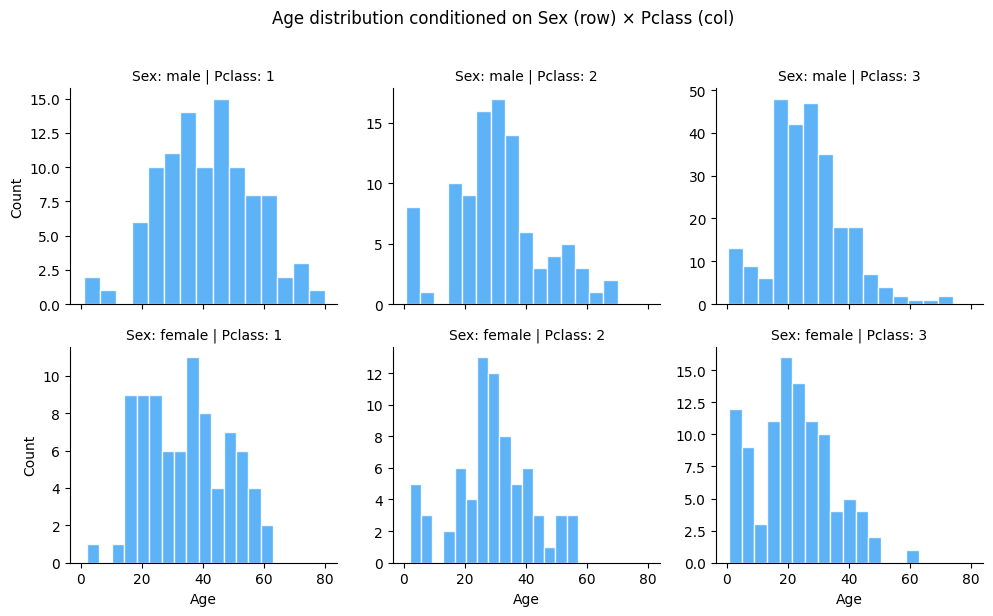

In [3]:
df = sns.load_dataset('titanic').dropna(subset=['age', 'embark_town'])

# ── Example 1: FacetGrid with histograms (row=sex, col=pclass) ──
g = sns.FacetGrid(df, row='sex', col='pclass',
                  height=3, aspect=1.1,
                  palette='husl', sharey=False)
g.map(plt.hist, 'age', bins=15, color='#42A5F5', edgecolor='white', alpha=0.85)
g.set_axis_labels('Age', 'Count')
g.set_titles(row_template='Sex: {row_name}', col_template='Pclass: {col_name}')
g.figure.suptitle('Age distribution conditioned on Sex (row) × Pclass (col)',
                   fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

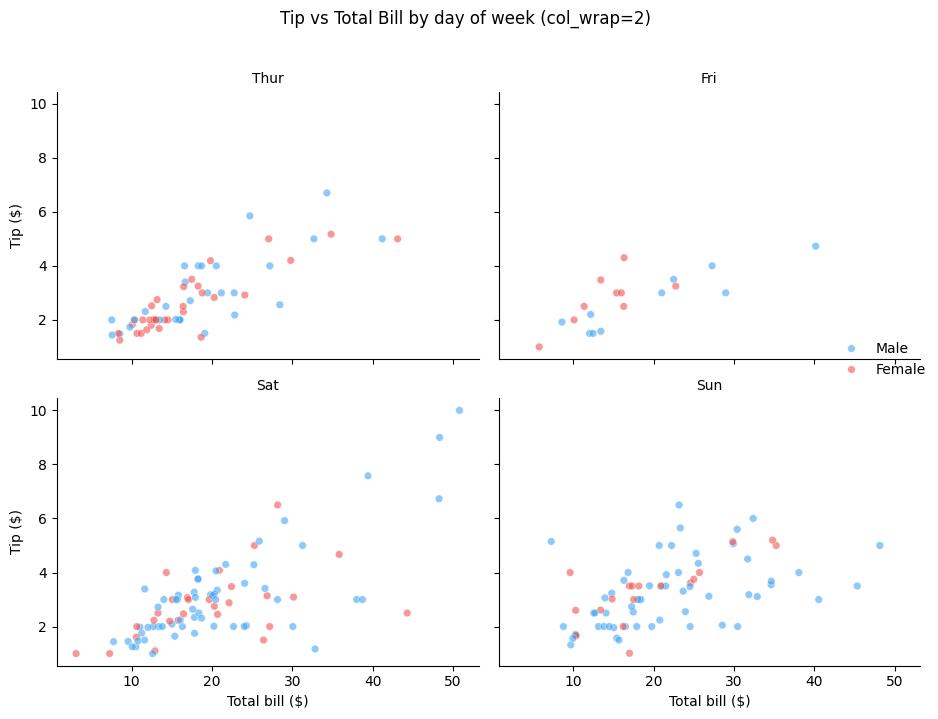

In [4]:
# ── Example 2: col_wrap for a variable with many levels ──
tips = sns.load_dataset('tips')

g2 = sns.FacetGrid(tips, col='day', col_wrap=2, height=3.5, aspect=1.2, sharey=True)
g2.map_dataframe(sns.scatterplot, x='total_bill', y='tip',
                 hue='sex', palette={'Male': '#42A5F5', 'Female': '#EF5350'},
                 alpha=0.6, s=30)
g2.add_legend()
g2.set_axis_labels('Total bill ($)', 'Tip ($)')
g2.set_titles(col_template='{col_name}')
g2.figure.suptitle('Tip vs Total Bill by day of week (col_wrap=2)',
                    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Visualising conditional relationships — how X~Y changes across groups |
| **`row=`** | Categorical variable that splits into rows |
| **`col=`** | Categorical variable that splits into columns |
| **`col_wrap=`** | Wraps columns into multiple rows when one variable has many levels |
| **`sharey=True`** | Shared y-axis — keeps comparisons fair; set `False` to zoom per panel |
| **Interaction** | Panel shape changes across row/col → feature interaction → candidate for interaction term |
| **vs pair plot** | Pair plot: all numeric pairs. Facet grid: any plot type conditioned on categorical |